In [1]:
from unicodedata import category

import kagglehub
from sqlalchemy import column

# Download latest version
path = kagglehub.dataset_download("dylanjcastillo/7k-books-with-metadata")

print("Path to dataset files:", path)

Path to dataset files: /Users/Bilal/.cache/kagglehub/datasets/dylanjcastillo/7k-books-with-metadata/versions/3


In [2]:
import pandas as pd

In [3]:
#This is the path of the dataset
books = pd.read_csv(f'{path}/books.csv')

In [4]:
books


,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6805,9788185300535,8185300534,I Am that,Talks with Sri Nisargadatta Maharaj,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0
6806,9788185944609,8185944601,Secrets Of The Heart,NaN,Khalil Gibran,Mysticism,http://books.google.com/books/content?id=XcrVp...,NaN,1993.0,4.08,74.0,324.0
6807,9788445074879,8445074873,Fahrenheit 451,NaN,Ray Bradbury,Book burning,NaN,NaN,2004.0,3.98,186.0,5733.0
6808,9789027712059,9027712050,The Berlin Phenomenology,NaN,Georg Wilhelm Friedrich Hegel,History,http://books.google.com/books/content?id=Vy7Sk...,Since the three volume edition ofHegel's Philo...,1981.0,0.00,210.0,0.0


In [5]:
pd.set_option('display.max_columns', None)


In [6]:
with pd.option_context('display.max_columns', None):
    print(books)

             isbn13      isbn10                      title  \
0     9780002005883  0002005883                     Gilead   
1     9780002261982  0002261987               Spider's Web   
2     9780006163831  0006163831               The One Tree   
3     9780006178736  0006178731             Rage of angels   
4     9780006280897  0006280897             The Four Loves   
...             ...         ...                        ...   
6805  9788185300535  8185300534                  I Am that   
6806  9788185944609  8185944601       Secrets Of The Heart   
6807  9788445074879  8445074873             Fahrenheit 451   
6808  9789027712059  9027712050   The Berlin Phenomenology   
6809  9789042003408  9042003405  'I'm Telling You Stories'   

                                            subtitle  \
0                                                NaN   
1                                            A Novel   
2                                                NaN   
3                              

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
#most popular categories are at the top and the least popular are at the bottom
books['categories'].value_counts().reset_index().sort_values('count', ascending=False)

,categories,count
0,Fiction,2588
1,Juvenile Fiction,538
2,Biography & Autobiography,401
3,History,264
4,Literary Criticism,166
...,...,...
304,Organized Crime,1
303,Autism,1
302,Botanique,1
301,English essays,1


In [9]:
ax = plt.axes

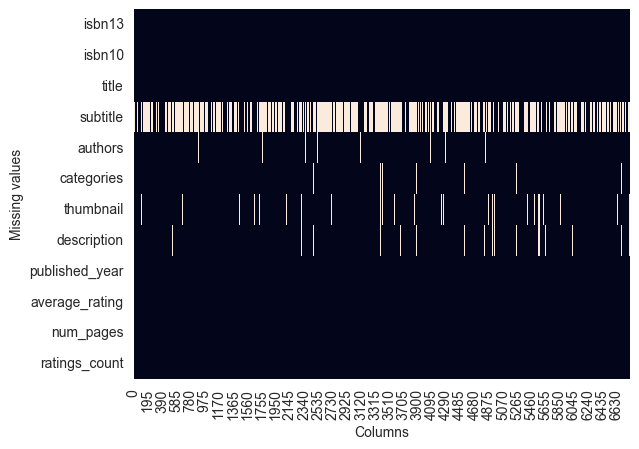

In [10]:
#creates a heatmap to see trends in the data
sns.heatmap(books.isnull().transpose(), cbar = False)

plt.xlabel('Columns')
plt.ylabel('Missing values')
#Black means missing
plt.show()


In [11]:
import numpy as np

books['missing_description'] = np.where(books['description'].isna(), 1, 0)
books['age_of_book'] = 2024 - books['published_year']

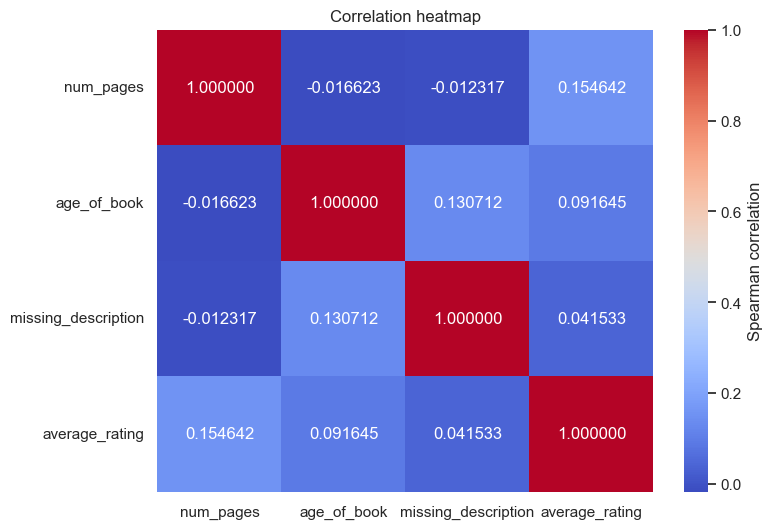

In [12]:
columns_of_interest = ['num_pages','age_of_book', 'missing_description', 'average_rating']
#I'm using spearman because the data is not continuous it's discrete
correlation_matrix = books[columns_of_interest].corr(method = 'spearman')

sns.set_theme(style = 'white')
plt.figure(figsize=(8,6))
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt = '2f', cmap = 'coolwarm',
                      cbar_kws={'label': 'Spearman correlation'})
#for this heatmap if num of pages had a missing description if both their correlations were close to 1
#or -1 that would mean that as the number of pages of a book increases or if the book is too long that
#could allow a book to have a missing descriptions which excludes longer books from the sample and that
#would introduce bias
heatmap.set_title("Correlation heatmap")
plt.show()

In [13]:
#| is an or & is an and, I'm removing the data with missing values completely by using a negation to not
#show them
missing_books = books[~(books['description'].isna()) &
      ~(books['num_pages'].isna()) &
      ~(books['average_rating'].isna()) &
      ~(books['published_year'].isna())
]
missing_books

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,missing_description,age_of_book
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,0,20.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,0,24.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0,0,42.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,0,31.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6803,9788173031014,8173031010,Journey to the East,NaN,Hermann Hesse,Adventure stories,http://books.google.com/books/content?id=rq6JP...,This book tells the tale of a man who goes on ...,2002.0,3.70,175.0,24.0,0,22.0
6804,9788179921623,817992162X,The Monk Who Sold His Ferrari: A Fable About F...,NaN,Robin Sharma,Health & Fitness,http://books.google.com/books/content?id=c_7mf...,"Wisdom to Create a Life of Passion, Purpose, a...",2003.0,3.82,198.0,1568.0,0,21.0
6805,9788185300535,8185300534,I Am that,Talks with Sri Nisargadatta Maharaj,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0,0,25.0
6808,9789027712059,9027712050,The Berlin Phenomenology,NaN,Georg Wilhelm Friedrich Hegel,History,http://books.google.com/books/content?id=Vy7Sk...,Since the three volume edition ofHegel's Philo...,1981.0,0.00,210.0,0.0,0,43.0


In [14]:
missing_books

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,missing_description,age_of_book
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,0,20.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,0,24.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0,0,42.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,0,31.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6803,9788173031014,8173031010,Journey to the East,NaN,Hermann Hesse,Adventure stories,http://books.google.com/books/content?id=rq6JP...,This book tells the tale of a man who goes on ...,2002.0,3.70,175.0,24.0,0,22.0
6804,9788179921623,817992162X,The Monk Who Sold His Ferrari: A Fable About F...,NaN,Robin Sharma,Health & Fitness,http://books.google.com/books/content?id=c_7mf...,"Wisdom to Create a Life of Passion, Purpose, a...",2003.0,3.82,198.0,1568.0,0,21.0
6805,9788185300535,8185300534,I Am that,Talks with Sri Nisargadatta Maharaj,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0,0,25.0
6808,9789027712059,9027712050,The Berlin Phenomenology,NaN,Georg Wilhelm Friedrich Hegel,History,http://books.google.com/books/content?id=Vy7Sk...,Since the three volume edition ofHegel's Philo...,1981.0,0.00,210.0,0.0,0,43.0


In [15]:
books


,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,missing_description,age_of_book
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,0,20.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,0,24.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0,0,42.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,0,31.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6805,9788185300535,8185300534,I Am that,Talks with Sri Nisargadatta Maharaj,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0,0,25.0
6806,9788185944609,8185944601,Secrets Of The Heart,NaN,Khalil Gibran,Mysticism,http://books.google.com/books/content?id=XcrVp...,NaN,1993.0,4.08,74.0,324.0,1,31.0
6807,9788445074879,8445074873,Fahrenheit 451,NaN,Ray Bradbury,Book burning,NaN,NaN,2004.0,3.98,186.0,5733.0,1,20.0
6808,9789027712059,9027712050,The Berlin Phenomenology,NaN,Georg Wilhelm Friedrich Hegel,History,http://books.google.com/books/content?id=Vy7Sk...,Since the three volume edition ofHegel's Philo...,1981.0,0.00,210.0,0.0,0,43.0


In [16]:
#creates a new variable called words in description and splits the string and gives the num of words in the lists
missing_books["words in description"] = missing_books['description'].str.split().str.len()
missing_books['words in description']

/var/folders/5z/5bf1hd4j5psgkv122dnz68_40000gq/T/ipykernel_7090/1205025518.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_books["words in description"] = missing_books['description'].str.split().str.len()


0       199
1       205
2        14
3        57
4        45
       ... 
6803     63
6804    117
6805    174
6808    245
6809     20
Name: words in description, Length: 6507, dtype: int64

In [17]:
missing_books.loc[missing_books['words in description'].between(1, 4), 'description']

6                                           Donation.
11                                     Fantasy-roman.
748              Includes bibliographical references.
770                             Bound For Oregon (PB)
775                                No Marketing Blurb
812                                No Marketing Blurb
857                          First published in 1813.
944                         Edited by Maurice Hindle.
953                        DEFOE/ROBINSON CRUSOE (BC)
954                             Edited by John Carey.
962                         ALLEN/GETTING THINGS DONE
1054                            GILBERT/EAT PRAY LOVE
1056    "Graham Greene centennial, 1904-2004"--Cover.
1060                   STEINBECK/GRAPES OF WRATH (BC)
1346                                   Fantasy-roman.
1546                                      Winter 2003
1610                                      Winter 1999
1813                             National bestseller.
1981                        

In [18]:
#this is the point where the description of the words are finally meaningful so I can remove the
#descriptions that came beforehand as they are useless
missing_books.loc[missing_books['words in description'].between(25, 34), 'description']


9       Kate Blackwell is an enigma and one of the mos...
14      Available in the U.S. for the first time, this...
20      It is 1937, and Charles Ashworth, a Canon to t...
21      Reissue of the author's most famous and well-l...
46      No one believes a little girl when she insists...
                              ...                        
6760    Joel, an English teacher, has never really lik...
6766    Discusses the historical and intellectual back...
6775    Presents nearly one thousand recipes--from app...
6779    Edited by the creator and executive producer o...
6799    This book is the story of a young girl obsesse...
Name: description, Length: 1229, dtype: object

In [19]:
#1000 books have been lost from me filtering them
book_missing_25_words = missing_books[missing_books['words in description'] >= 25]
book_missing_25_words

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,missing_description,age_of_book,words in description
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,0,20.0,199
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,0,24.0,205
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,0,31.0,57
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,0,22.0,45
5,9780006280934,0006280935,The Problem of Pain,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=Kk-uV...,"""In The Problem of Pain, C.S. Lewis, one of th...",2002.0,4.09,176.0,37569.0,0,22.0,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6802,9788172235222,8172235224,Mistaken Identity,NaN,Nayantara Sahgal,Indic fiction (English),http://books.google.com/books/content?id=q-tKP...,On A Train Journey Home To North India After L...,2003.0,2.93,324.0,0.0,0,21.0,288
6803,9788173031014,8173031010,Journey to the East,NaN,Hermann Hesse,Adventure stories,http://books.google.com/books/content?id=rq6JP...,This book tells the tale of a man who goes on ...,2002.0,3.70,175.0,24.0,0,22.0,63
6804,9788179921623,817992162X,The Monk Who Sold His Ferrari: A Fable About F...,NaN,Robin Sharma,Health & Fitness,http://books.google.com/books/content?id=c_7mf...,"Wisdom to Create a Life of Passion, Purpose, a...",2003.0,3.82,198.0,1568.0,0,21.0,117
6805,9788185300535,8185300534,I Am that,Talks with Sri Nisargadatta Maharaj,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0,0,25.0,174


In [43]:
#this removes the subtitles and title since it uses isna, and then joins title and subtitle together in a single variable where words with a subtitle now have the title next to the subtitle
#books_missing_25_words_copy = book_missing_25_words.copy()
book_missing_25_words['title_and_subtitle'] = np.where(
    book_missing_25_words['subtitle'].isna(),
    book_missing_25_words['title'],  # Use title when subtitle is missing
    book_missing_25_words[['title', 'subtitle']].astype(str).agg(':'.join, axis=1)  # Join title:subtitle when both exist
)

book_missing_25_words

/var/folders/5z/5bf1hd4j5psgkv122dnz68_40000gq/T/ipykernel_7090/1733256906.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  book_missing_25_words['title_and_subtitle'] = np.where(


,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,missing_description,age_of_book,words in description,title_and_subtitle,tagged_description
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,0,20.0,199,Gilead,9780002005883 A NOVEL THAT READERS and critics...
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,0,24.0,205,Spider's Web:A Novel,9780002261982 A new 'Christie for Christmas' -...
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,0,31.0,57,Rage of angels,"9780006178736 A memorable, mesmerizing heroine..."
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,0,22.0,45,The Four Loves,9780006280897 Lewis' work on the nature of lov...
5,9780006280934,0006280935,The Problem of Pain,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=Kk-uV...,"""In The Problem of Pain, C.S. Lewis, one of th...",2002.0,4.09,176.0,37569.0,0,22.0,75,The Problem of Pain,"9780006280934 ""In The Problem of Pain, C.S. Le..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6802,9788172235222,8172235224,Mistaken Identity,NaN,Nayantara Sahgal,Indic fiction (English),http://books.google.com/books/content?id=q-tKP...,On A Train Journey Home To North India After L...,2003.0,2.93,324.0,0.0,0,21.0,288,Mistaken Identity,9788172235222 On A Train Journey Home To North...
6803,9788173031014,8173031010,Journey to the East,NaN,Hermann Hesse,Adventure stories,http://books.google.com/books/content?id=rq6JP...,This book tells the tale of a man who goes on ...,2002.0,3.70,175.0,24.0,0,22.0,63,Journey to the East,9788173031014 This book tells the tale of a ma...
6804,9788179921623,817992162X,The Monk Who Sold His Ferrari: A Fable About F...,NaN,Robin Sharma,Health & Fitness,http://books.google.com/books/content?id=c_7mf...,"Wisdom to Create a Life of Passion, Purpose, a...",2003.0,3.82,198.0,1568.0,0,21.0,117,The Monk Who Sold His Ferrari: A Fable About F...,9788179921623 Wisdom to Create a Life of Passi...
6805,9788185300535,8185300534,I Am that,Talks with Sri Nisargadatta Maharaj,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0,0,25.0,174,I Am that:Talks with Sri Nisargadatta Maharaj,9788185300535 This collection of the timeless ...


In [44]:
book_missing_25_words['title_and_subtitle']

0                                                  Gilead
1                                    Spider's Web:A Novel
3                                          Rage of angels
4                                          The Four Loves
5                                     The Problem of Pain
                              ...                        
6802                                    Mistaken Identity
6803                                  Journey to the East
6804    The Monk Who Sold His Ferrari: A Fable About F...
6805        I Am that:Talks with Sri Nisargadatta Maharaj
6808                             The Berlin Phenomenology
Name: title_and_subtitle, Length: 5197, dtype: object

In [45]:
#I'm joining the isb13 with the description to provide a unique identifier database in the table


book_missing_25_words["tagged_description"] = book_missing_25_words[['isbn13','description' ]].astype(str).agg(" ".join, axis =1)


book_missing_25_words['tagged_description']

/var/folders/5z/5bf1hd4j5psgkv122dnz68_40000gq/T/ipykernel_7090/1041003240.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  book_missing_25_words["tagged_description"] = book_missing_25_words[['isbn13','description' ]].astype(str).agg(" ".join, axis =1)


0       9780002005883 A NOVEL THAT READERS and critics...
1       9780002261982 A new 'Christie for Christmas' -...
3       9780006178736 A memorable, mesmerizing heroine...
4       9780006280897 Lewis' work on the nature of lov...
5       9780006280934 "In The Problem of Pain, C.S. Le...
                              ...                        
6802    9788172235222 On A Train Journey Home To North...
6803    9788173031014 This book tells the tale of a ma...
6804    9788179921623 Wisdom to Create a Life of Passi...
6805    9788185300535 This collection of the timeless ...
6808    9789027712059 Since the three volume edition o...
Name: tagged_description, Length: 5197, dtype: object

In [46]:
#for llms a probability tree is made for each word based on the words that precede it and the words that come after it, example if the word the comes before best in several case scenerio then the most likely word to come before the word best is used the, therefore the LLM will have a prediction pattern of using the before most 'bests'. This is called a word embedding model . However this models shortcomings come in the form of them being bad at getting the context, such as 'river bank' uses the word bank very differently from the words 'the bank on...'
# First, make sure the CSV was created properly
book_missing_25_words.drop(
    ['subtitle', 'missing_description', 'age_of_book'], axis=1).to_csv('books_cleaned.csv', index=False)



In [47]:
#if a probability of a sentence is high, that probability signifies that in this specific case the text/word/sentence is appropiate. Example for the history section, the phrase 'the decline of the roman empire', would have a very high probability for the history probability, whilst the word 'the cat ate ice cream' would have a low probability for history, each phrase like in a description can be given a unique id value that can be used to correlate the probabilities the descriptions being similar to a specific category, the id can be used to retrieve important stuff about it, like the description, author etc.

In [48]:
#converts the text into a format that langchain can work with
from langchain_community.document_loaders import TextLoader
#seperates long descriptions into meaningful chunks, these are the descriptions of each book
from langchain_text_splitters import CharacterTextSplitter
#converting chunks into document embeddings(numerical representations of documents)
from langchain_openai import OpenAIEmbeddings
#Chroma will be used to store the numerical values in a vector database
from langchain_chroma import Chroma

In [49]:
from dotenv import load_dotenv
load_dotenv()

True

In [50]:
import pandas as pd
books = pd.read_csv('books_cleaned.csv')

In [51]:
books['tagged_description']

0       9780002005883 A NOVEL THAT READERS and critics...
1       9780002261982 A new 'Christie for Christmas' -...
2       9780006178736 A memorable, mesmerizing heroine...
3       9780006280897 Lewis' work on the nature of lov...
4       9780006280934 "In The Problem of Pain, C.S. Le...
                              ...                        
5192    9788172235222 On A Train Journey Home To North...
5193    9788173031014 This book tells the tale of a ma...
5194    9788179921623 Wisdom to Create a Life of Passi...
5195    9788185300535 This collection of the timeless ...
5196    9789027712059 Since the three volume edition o...
Name: tagged_description, Length: 5197, dtype: object

In [52]:
books['tagged_description'].to_csv('tagged_description.txt',
                                   index=False,
                                   header=False)

In [53]:
#raw_documents = TextLoader('tagged_description.txt').load()
#text_splitter = CharacterTextSplitter(chunk_size=0, chunk_overlap=0, separator='\n')
#documents = text_splitter.split_documents(raw_documents)
from langchain_core.documents import Document

# Skip text splitting entirely - make each description its own document
#all the descriptions are split up and put in 1 document and each line is a description, an AI can work with text documents
documents = [
    Document(page_content=str(desc))
    for desc in books['tagged_description']
    if pd.notna(desc)  # Skip NaN values
]

In [54]:
documents[0]

Document(metadata={}, page_content='9780002005883 A NOVEL THAT READERS and critics have been eagerly anticipating for over a decade, Gilead is an astonishingly imagined story of remarkable lives. John Ames is a preacher, the son of a preacher and the grandson (both maternal and paternal) of preachers. It’s 1956 in Gilead, Iowa, towards the end of the Reverend Ames’s life, and he is absorbed in recording his family’s story, a legacy for the young son he will never see grow up. Haunted by his grandfather’s presence, John tells of the rift between his grandfather and his father: the elder, an angry visionary who fought for the abolitionist cause, and his son, an ardent pacifist. He is troubled, too, by his prodigal namesake, Jack (John Ames) Boughton, his best friend’s lost son who returns to Gilead searching for forgiveness and redemption. Told in John Ames’s joyous, rambling voice that finds beauty, humour and truth in the smallest of life’s details, Gilead is a song of celebration and 

In [55]:
#db_books = Chroma.from_documents(
#    documents,
#    embedding=OpenAIEmbeddings())

In [56]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

#this is a free embedding model
# Free embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Create embeddings from your documents
#An embedding is basically creating a vector matrix of the probability values that are similar to each other and grouping them with each other
embeddings = model.encode([doc.page_content for doc in documents])

# Create FAISS vector database (free alternative to Chroma)
#checks the number of book descriptions of each book
dimension = embeddings.shape[1]
#this creates a search engine that can find similar patterns
index = faiss.IndexFlatIP(dimension)  # Inner product similarity
#all the book numbers are added to the search engine, and float32 is the right format
index.add(embeddings.astype('float32'))

# Store documents for retrieval
#original book descriptions are then stored
document_store = documents

In [57]:
# To find similar books to a query
def find_similar_books(query_text, k=10):
    # Convert your search into numbers
    query_embedding = model.encode([query_text])

    # Search for similar number patterns

    scores, indices = index.search(query_embedding.astype('float32'), k)

    # Get the actual book descriptions
    similar_books = [document_store[i] for i in indices[0]]

    return similar_books

# Example usage
similar = find_similar_books("", k=10)
for book in similar:
    print(book.page_content)

9781593075293 With the world reeling from the after effects of a brutal, widespread virus, civilization is torn between the laws and ways of the old world and a new order where cybernetic implants are commonplace and might means right. Elijah and his comrades-in-arms attempt to cross the Andes Mountains, with Propater's gruesome Aeon soldiers and armored troops hot on their heels.
9781584281344 Jeff Smith teaches surefire techniques for achieving flattering results, detailing the principles of posing the entire body - head, shoulders, arms, hands, bust, waist, hips, thighs and feet. With an emphasis on creating images that will sell themselves, readers will learn to correct common figure problems and design poses that look natural, crafting images that clients are sure to love.
9780812534832 Two young adventurers are drawn into the world of Xanth through a computer game and find themselves in a desperate race against time when treachery, danger, and deceit place Xanth itself in peril, 

In [60]:
books[books["isbn13"]] == int(similar[0].page_content.split()[0].strip())

KeyError: "None of [Index([9780002005883, 9780002261982, 9780006178736, 9780006280897,\n       9780006280934, 9780006380832, 9780006470229, 9780006472612,\n       9780006482079, 9780006483014,\n       ...\n       9784770028037, 9784770028969, 9788122200850, 9788125026600,\n       9788171565641, 9788172235222, 9788173031014, 9788179921623,\n       9788185300535, 9789027712059],\n      dtype='int64', length=5197)] are in the [columns]"

In [63]:
#an isbn is 10 digits
def retrieve_semantic_recommender(
        query:str,
        top_k:int=10,
) -> pd.DataFrame:
    rec = find_similar_books(query, k=50)
    books_list = []

    for i in range(len(rec)):
        try:
            # Extract ISBN from the document content
            content = rec[i].page_content.strip('"')
            isbn = int(content.split()[0])
            books_list.append(isbn)
        except (ValueError, IndexError):
            # Skip if can't extract ISBN
            continue

    # Filter books by ISBNs and return top results
    filtered_books = books[books["isbn13"].isin(books_list)]
    return filtered_books.head(top_k)

In [64]:
# Test it
retrieve_semantic_recommender("a depressed family going to hardship because of poverty")

,isbn13,isbn10,title,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,words in description,title_and_subtitle,tagged_description
148,9780060564780,0060564784,The Kindness of Strangers,Katrina Kittle,Fiction,http://books.google.com/books/content?id=nDhTB...,"A young widow raising two boys, Sarah Laden is...",2007.0,4.01,400.0,11432.0,114,The Kindness of Strangers,"9780060564780 A young widow raising two boys, ..."
214,9780060760250,0060760257,Charms for the Easy Life,Kaye Gibbons,Fiction,http://books.google.com/books/content?id=TE2mB...,"A family without men, the Birches live gloriou...",2005.0,4.02,272.0,10983.0,161,Charms for the Easy Life,"9780060760250 A family without men, the Birche..."
312,9780060936198,0060936193,The Girl in the Glass,Jeffrey Ford,Fiction,http://books.google.com/books/content?id=mgYTl...,The Great Depression has bound a nation in des...,2005.0,3.72,304.0,756.0,168,The Girl in the Glass:A Novel,9780060936198 The Great Depression has bound a...
337,9780060977498,0060977493,The God of Small Things,Arundhati Roy,Fiction,http://books.google.com/books/content?id=2GESv...,A debut novel of dark foreboding and family tr...,1998.0,3.93,321.0,6549.0,38,The God of Small Things,9780060977498 A debut novel of dark foreboding...
610,9780140271577,0140271570,Solomon's Song,Bryce Courtenay,Australia,http://books.google.com/books/content?id=rYd_A...,'This is the story of two families - branches ...,2000.0,4.01,671.0,3767.0,60,Solomon's Song,9780140271577 'This is the story of two famili...
615,9780140276336,0140276335,White Teeth,Zadie Smith,Fiction,http://books.google.com/books/content?id=EIjEr...,"In the author's words, this novel is an attemp...",2001.0,3.76,542.0,3859.0,52,White Teeth,"9780140276336 In the author's words, this nove..."
793,9780142002001,0142002003,Youth,J. M. Coetzee,Fiction,http://books.google.com/books/content?id=Mh9EP...,"Hoping to escape his South African home, dysfu...",2003.0,3.79,176.0,4722.0,43,Youth,9780142002001 Hoping to escape his South Afric...
825,9780142437018,0142437018,A Little Princess,Frances Hodgson Burnett,Fiction,http://books.google.com/books/content?id=7_8uF...,"Sara Crewe, a pupil at Miss Minchin's London s...",2002.0,4.19,242.0,232387.0,25,A Little Princess,"9780142437018 Sara Crewe, a pupil at Miss Minc..."
872,9780143039853,0143039857,The Outsiders,S. E. Hinton;Jodi Picoult,Fiction,http://books.google.com/books/content?id=9PyIP...,The struggle of three brothers to stay togethe...,1967.0,4.08,160.0,1558.0,25,The Outsiders,9780143039853 The struggle of three brothers t...
910,9780156030489,0156030489,Kiffe Kiffe Tomorrow,Faïza Guène;Sarah Adams,Fiction,http://books.google.com/books/content?id=fv8tv...,"Struggling with an overworked mother, an absen...",2006.0,3.38,179.0,1026.0,50,Kiffe Kiffe Tomorrow,9780156030489 Struggling with an overworked mo...


In [65]:
books["categories"]

0                             Fiction
1       Detective and mystery stories
2                             Fiction
3                      Christian life
4                      Christian life
                    ...              
5192          Indic fiction (English)
5193                Adventure stories
5194                 Health & Fitness
5195                       Philosophy
5196                          History
Name: categories, Length: 5197, dtype: object

In [66]:
books['categories'].value_counts().reset_index().query('count > 50')

,categories,count
0,Fiction,2111
1,Juvenile Fiction,390
2,Biography & Autobiography,311
3,History,207
4,Literary Criticism,124
5,Philosophy,117
6,Religion,117
7,Comics & Graphic Novels,116
8,Drama,86
9,Juvenile Nonfiction,57


In [67]:
category_mapping = {"Fiction":"Fiction",
"Juvenile Fiction":"Children's Fiction",
"Biography & Autobiography" : "Nonfiction",
"History" : "Nonfiction",
"Literary Criticism" : "Nonfiction",
"Philosophy" : "Nonfiction",
"Religion" : "Nonfiction",
"Comics & Graphic Novels" : "Fiction",
"Drama" : "Fiction",
"Juvenile Nonfiction" : "Children's Nonfiction",
"Science" : "Nonfiction",
"Poetry" : "Fiction"}

books["simple categories"] = books['categories'].map(category_mapping)

In [68]:
books[~(books["simple categories"].isna())]

,isbn13,isbn10,title,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,words in description,title_and_subtitle,tagged_description,simple categories
0,9780002005883,0002005883,Gilead,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,199,Gilead,9780002005883 A NOVEL THAT READERS and critics...,Fiction
2,9780006178736,0006178731,Rage of angels,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,57,Rage of angels,"9780006178736 A memorable, mesmerizing heroine...",Fiction
8,9780006482079,0006482074,Warhost of Vastmark,Janny Wurts,Fiction,http://books.google.com/books/content?id=uOL0f...,"Tricked once more by his wily half-brother, Ly...",1995.0,4.03,522.0,2966.0,136,Warhost of Vastmark,9780006482079 Tricked once more by his wily ha...,Fiction
30,9780006646006,000664600X,Ocean Star Express,Mark Haddon;Peter Sutton,Juvenile Fiction,http://books.google.com/books/content?id=I2QZA...,Joe and his parents are enjoying a summer holi...,2002.0,3.50,32.0,1.0,129,Ocean Star Express,9780006646006 Joe and his parents are enjoying...,Children's Fiction
46,9780007121014,0007121016,Taken at the Flood,Agatha Christie,Fiction,http://books.google.com/books/content?id=3gWlx...,A Few Weeks After Marrying An Attractive Young...,2002.0,3.71,352.0,8852.0,100,Taken at the Flood,9780007121014 A Few Weeks After Marrying An At...,Fiction
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5178,9781933648279,1933648279,Night Has a Thousand Eyes,Cornell Woolrich,Fiction,http://books.google.com/books/content?id=3Gk6s...,"""Cornell Woolrich's novels define the essence ...",2007.0,3.77,344.0,680.0,100,Night Has a Thousand Eyes,"9781933648279 ""Cornell Woolrich's novels defin...",Fiction
5188,9784770028969,4770028962,Coin Locker Babies,村上龍,Fiction,http://books.google.com/books/content?id=87DJw...,Rescued from the lockers in which they were le...,2002.0,3.75,393.0,5560.0,41,Coin Locker Babies,9784770028969 Rescued from the lockers in whic...,Fiction
5189,9788122200850,8122200850,"Cry, the Peacock",Anita Desai,Fiction,http://books.google.com/books/content?id=_QKwV...,This book is the story of a young girl obsesse...,1980.0,3.22,218.0,134.0,33,"Cry, the Peacock",9788122200850 This book is the story of a youn...,Fiction
5195,9788185300535,8185300534,I Am that,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0,174,I Am that:Talks with Sri Nisargadatta Maharaj,9788185300535 This collection of the timeless ...,Nonfiction


In [69]:
books


,isbn13,isbn10,title,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,words in description,title_and_subtitle,tagged_description,simple categories
0,9780002005883,0002005883,Gilead,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,199,Gilead,9780002005883 A NOVEL THAT READERS and critics...,Fiction
1,9780002261982,0002261987,Spider's Web,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,205,Spider's Web:A Novel,9780002261982 A new 'Christie for Christmas' -...,NaN
2,9780006178736,0006178731,Rage of angels,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,57,Rage of angels,"9780006178736 A memorable, mesmerizing heroine...",Fiction
3,9780006280897,0006280897,The Four Loves,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,45,The Four Loves,9780006280897 Lewis' work on the nature of lov...,NaN
4,9780006280934,0006280935,The Problem of Pain,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=Kk-uV...,"""In The Problem of Pain, C.S. Lewis, one of th...",2002.0,4.09,176.0,37569.0,75,The Problem of Pain,"9780006280934 ""In The Problem of Pain, C.S. Le...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5192,9788172235222,8172235224,Mistaken Identity,Nayantara Sahgal,Indic fiction (English),http://books.google.com/books/content?id=q-tKP...,On A Train Journey Home To North India After L...,2003.0,2.93,324.0,0.0,288,Mistaken Identity,9788172235222 On A Train Journey Home To North...,NaN
5193,9788173031014,8173031010,Journey to the East,Hermann Hesse,Adventure stories,http://books.google.com/books/content?id=rq6JP...,This book tells the tale of a man who goes on ...,2002.0,3.70,175.0,24.0,63,Journey to the East,9788173031014 This book tells the tale of a ma...,NaN
5194,9788179921623,817992162X,The Monk Who Sold His Ferrari: A Fable About F...,Robin Sharma,Health & Fitness,http://books.google.com/books/content?id=c_7mf...,"Wisdom to Create a Life of Passion, Purpose, a...",2003.0,3.82,198.0,1568.0,117,The Monk Who Sold His Ferrari: A Fable About F...,9788179921623 Wisdom to Create a Life of Passi...,NaN
5195,9788185300535,8185300534,I Am that,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0,174,I Am that:Talks with Sri Nisargadatta Maharaj,9788185300535 This collection of the timeless ...,Nonfiction


In [73]:
from transformers import pipeline
pipe = pipeline("zero-shot-classification",
                model="facebook/bart-large-mnli",
                device= "mps")

Device set to use mps


In [74]:
fiction_categories = ['Fiction', "Nonfiction"]
sequence = books.loc[books['simple categories'] == 'Fiction', 'description'].reset_index(drop=True)[0]

In [75]:
pipe(sequence, fiction_categories)

{'sequence': 'A NOVEL THAT READERS and critics have been eagerly anticipating for over a decade, Gilead is an astonishingly imagined story of remarkable lives. John Ames is a preacher, the son of a preacher and the grandson (both maternal and paternal) of preachers. It’s 1956 in Gilead, Iowa, towards the end of the Reverend Ames’s life, and he is absorbed in recording his family’s story, a legacy for the young son he will never see grow up. Haunted by his grandfather’s presence, John tells of the rift between his grandfather and his father: the elder, an angry visionary who fought for the abolitionist cause, and his son, an ardent pacifist. He is troubled, too, by his prodigal namesake, Jack (John Ames) Boughton, his best friend’s lost son who returns to Gilead searching for forgiveness and redemption. Told in John Ames’s joyous, rambling voice that finds beauty, humour and truth in the smallest of life’s details, Gilead is a song of celebration and acceptance of the best and the worst

In [76]:
import numpy as np
max_index = np.argmax(pipe(sequence, fiction_categories)['scores'])
max_label = pipe(sequence, fiction_categories)['labels'][max_index]
max_label

'Fiction'

In [77]:
def generate_prediction(sequence, categories):
    predictions = pipe(sequence, categories)
    max_index = np.argmax(predictions['scores'])
    max_label = pipe(sequence, categories)['labels'][max_index]
    return max_label

In [80]:
from tqdm import tqdm

actual_cats = []
predicted_cats = []

for i in tqdm(range(1, 300)):
    sequence = books.loc[books['simple categories'] == 'Fiction', 'description'].reset_index(drop=True)[i]
    predicted_cats += [generate_prediction(sequence, fiction_categories)]
    actual_cats += ['Fiction']


100%|██████████| 299/299 [03:51<00:00,  1.29it/s]


In [81]:
from tqdm import tqdm

actual_cats = []
predicted_cats = []

for i in tqdm(range(1, 300)):
    sequence = books.loc[books['simple categories'] == 'Nonfiction', 'description'].reset_index(drop=True)[i]
    predicted_cats += [generate_prediction(sequence, fiction_categories)]
    actual_cats += ['Nonfiction']


100%|██████████| 299/299 [04:04<00:00,  1.22it/s]


In [82]:
prediction_df = pd.DataFrame({"actual_categories": actual_cats, "predicted_categories": predicted_cats})

In [83]:
prediction_df

,actual_categories,predicted_categories
0,Nonfiction,Nonfiction
1,Nonfiction,Nonfiction
2,Nonfiction,Fiction
3,Nonfiction,Nonfiction
4,Nonfiction,Nonfiction
...,...,...
294,Nonfiction,Nonfiction
295,Nonfiction,Fiction
296,Nonfiction,Nonfiction
297,Nonfiction,Nonfiction


In [84]:
prediction_df["correct_predictions"] = (
    np.where(prediction_df["actual_categories"] == prediction_df["predicted_categories"], 1, 0)
)

In [85]:
prediction_df['correct_predictions'].sum() / len(prediction_df)

np.float64(0.8762541806020067)

In [86]:
isbns = []
predicted_cats = []

missing_cats = books.loc[books['simple categories'].isna(), ['isbn13', 'description']].reset_index(drop=True)

In [87]:
for i in tqdm(range(0, len(missing_cats))):
    sequence = missing_cats['description'][i]
    predicted_cats += [generate_prediction(sequence, fiction_categories)]
    isbns.append(missing_cats['isbn13'][i])

100%|██████████| 1454/1454 [15:46<00:00,  1.54it/s]


In [88]:
missing_predicted_df = pd.DataFrame({"isbn13": isbns, "predicted_categories": predicted_cats})

In [89]:
missing_predicted_df

,isbn13,predicted_categories
0,9780002261982,Fiction
1,9780006280897,Nonfiction
2,9780006280934,Nonfiction
3,9780006380832,Nonfiction
4,9780006470229,Fiction
...,...,...
1449,9788125026600,Nonfiction
1450,9788171565641,Fiction
1451,9788172235222,Fiction
1452,9788173031014,Nonfiction


In [90]:
books = pd.merge(books, missing_predicted_df, how='left', on='isbn13')
#where the categories are empty, the classifier classifies them to provide each book with a category
books['simple categories'] = np.where(books['simple categories'].isna(), books['predicted_categories'], books['simple categories'])
books = books.drop(columns=['predicted_categories'])

In [91]:
books.columns

Index(['isbn13', 'isbn10', 'title', 'authors', 'categories', 'thumbnail',
       'description', 'published_year', 'average_rating', 'num_pages',
       'ratings_count', 'words in description', 'title_and_subtitle',
       'tagged_description', 'simple categories'],
      dtype='object')

In [92]:
from transformers import pipeline
classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base",
                      return_all_scores=True,
                    top_k = None,
                     device = 'mps')
classifier("I love this!")

Device set to use mps


[[{'label': 'joy', 'score': 0.9771687984466553},
  {'label': 'surprise', 'score': 0.008528691716492176},
  {'label': 'neutral', 'score': 0.005764603149145842},
  {'label': 'anger', 'score': 0.004419785924255848},
  {'label': 'sadness', 'score': 0.0020923931151628494},
  {'label': 'disgust', 'score': 0.0016119939973577857},
  {'label': 'fear', 'score': 0.0004138521908316761}]]

In [93]:
books['description'][0]

'A NOVEL THAT READERS and critics have been eagerly anticipating for over a decade, Gilead is an astonishingly imagined story of remarkable lives. John Ames is a preacher, the son of a preacher and the grandson (both maternal and paternal) of preachers. It’s 1956 in Gilead, Iowa, towards the end of the Reverend Ames’s life, and he is absorbed in recording his family’s story, a legacy for the young son he will never see grow up. Haunted by his grandfather’s presence, John tells of the rift between his grandfather and his father: the elder, an angry visionary who fought for the abolitionist cause, and his son, an ardent pacifist. He is troubled, too, by his prodigal namesake, Jack (John Ames) Boughton, his best friend’s lost son who returns to Gilead searching for forgiveness and redemption. Told in John Ames’s joyous, rambling voice that finds beauty, humour and truth in the smallest of life’s details, Gilead is a song of celebration and acceptance of the best and the worst the world ha

In [94]:
classifier(books['description'][0])

[[{'label': 'fear', 'score': 0.6548412442207336},
  {'label': 'neutral', 'score': 0.16985206305980682},
  {'label': 'sadness', 'score': 0.11640891432762146},
  {'label': 'surprise', 'score': 0.020700661465525627},
  {'label': 'disgust', 'score': 0.019100770354270935},
  {'label': 'joy', 'score': 0.015161288902163506},
  {'label': 'anger', 'score': 0.003935153596103191}]]

In [95]:
classifier(books['description'][0].split('.'))

[[{'label': 'surprise', 'score': 0.7296032905578613},
  {'label': 'neutral', 'score': 0.14038535952568054},
  {'label': 'fear', 'score': 0.06816209107637405},
  {'label': 'joy', 'score': 0.047942325472831726},
  {'label': 'anger', 'score': 0.009156342595815659},
  {'label': 'disgust', 'score': 0.002628472400829196},
  {'label': 'sadness', 'score': 0.0021221591159701347}],
 [{'label': 'neutral', 'score': 0.4493713974952698},
  {'label': 'disgust', 'score': 0.27359098196029663},
  {'label': 'joy', 'score': 0.10908278077840805},
  {'label': 'sadness', 'score': 0.09362737089395523},
  {'label': 'anger', 'score': 0.04047822952270508},
  {'label': 'surprise', 'score': 0.026970190927386284},
  {'label': 'fear', 'score': 0.006879057735204697}],
 [{'label': 'neutral', 'score': 0.6462154984474182},
  {'label': 'sadness', 'score': 0.24273385107517242},
  {'label': 'disgust', 'score': 0.04342261701822281},
  {'label': 'surprise', 'score': 0.028300536796450615},
  {'label': 'joy', 'score': 0.014211

In [96]:
sentence = (books['description'][0].split('.'))
prediction = classifier(sentence)
prediction[0]

[{'label': 'surprise', 'score': 0.7296032905578613},
 {'label': 'neutral', 'score': 0.14038535952568054},
 {'label': 'fear', 'score': 0.06816209107637405},
 {'label': 'joy', 'score': 0.047942325472831726},
 {'label': 'anger', 'score': 0.009156342595815659},
 {'label': 'disgust', 'score': 0.002628472400829196},
 {'label': 'sadness', 'score': 0.0021221591159701347}]

In [97]:
sentence[0]

'A NOVEL THAT READERS and critics have been eagerly anticipating for over a decade, Gilead is an astonishingly imagined story of remarkable lives'

In [98]:
sentence[4]

' He is troubled, too, by his prodigal namesake, Jack (John Ames) Boughton, his best friend’s lost son who returns to Gilead searching for forgiveness and redemption'

In [99]:
prediction[4]

[{'label': 'sadness', 'score': 0.9671574234962463},
 {'label': 'neutral', 'score': 0.015104183927178383},
 {'label': 'disgust', 'score': 0.006480601150542498},
 {'label': 'fear', 'score': 0.005393999628722668},
 {'label': 'surprise', 'score': 0.0022869426757097244},
 {'label': 'anger', 'score': 0.0018428884213790298},
 {'label': 'joy', 'score': 0.0017338803736492991}]

In [100]:
#sorts all the emotions in the same order regardless of which one has the highest probability
sorted(prediction[0], key = lambda x: x['label'])

[{'label': 'anger', 'score': 0.009156342595815659},
 {'label': 'disgust', 'score': 0.002628472400829196},
 {'label': 'fear', 'score': 0.06816209107637405},
 {'label': 'joy', 'score': 0.047942325472831726},
 {'label': 'neutral', 'score': 0.14038535952568054},
 {'label': 'sadness', 'score': 0.0021221591159701347},
 {'label': 'surprise', 'score': 0.7296032905578613}]

In [105]:
import numpy

emotions_label = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
isbn = []
emotion_scores = {label : [] for label in emotions_label}

def calculate_max_emotion_score(predictions):
    per_emotion_scores = {label: [] for label in emotions_label}

    # Process each sentence's predictions
    for prediction in predictions:
        # For each emotion, find its score in this sentence
        for label in emotions_label:
            # Find the score for this specific emotion label
            emotion_score = next((item['score'] for item in prediction if item['label'] == label), 0.0)
            per_emotion_scores[label].append(emotion_score)

    # Return the maximum score for each emotion across all sentences
    return {label: np.max(scores) if scores else 0.0 for label, scores in per_emotion_scores.items()}


In [106]:
for i in range(10):
    isbn.append(books['isbn13'][i])
    sentences = books['description'][i].split('.')
    predictions = classifier(sentences)
    max_scores = calculate_max_emotion_score(predictions)
    for label in emotions_label:
        emotion_scores[label].append(max_scores[label])


In [111]:
emotion_scores

{'anger': [np.float64(0.06413351744413376),
  np.float64(0.6126188039779663),
  np.float64(0.06413351744413376),
  np.float64(0.351483553647995),
  np.float64(0.0814124271273613),
  np.float64(0.23222501575946808),
  np.float64(0.5381842255592346),
  np.float64(0.06413351744413376),
  np.float64(0.3006700873374939),
  np.float64(0.06413351744413376),
  np.float64(0.06413351744413376),
  np.float64(0.611574649810791),
  np.float64(0.10621488094329834),
  np.float64(0.06413351744413376),
  np.float64(0.07239244878292084),
  np.float64(0.09586330503225327),
  np.float64(0.16215911507606506),
  np.float64(0.06413351744413376),
  np.float64(0.08193860203027725),
  np.float64(0.2234598845243454),
  np.float64(0.10715216398239136),
  np.float64(0.06413351744413376),
  np.float64(0.06413351744413376),
  np.float64(0.06413351744413376),
  np.float64(0.39636605978012085),
  np.float64(0.06472668051719666),
  np.float64(0.06413351744413376),
  np.float64(0.06413351744413376),
  np.float64(0.06413

In [109]:
from tqdm import tqdm

emotions_label = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
isbn = []
emotion_scores = {label : [] for label in emotions_label}

for i in tqdm(range(len(books))):
    isbn.append(books['isbn13'][i])
    sentences = books['description'][i].split('.')
    predictions = classifier(sentences)
    max_scores = calculate_max_emotion_score(predictions)
    for label in emotions_label:
        emotion_scores[label].append(max_scores[label])


100%|██████████| 5197/5197 [2:09:11<00:00,  1.49s/it]    


In [112]:
emotions_df = pd.DataFrame(emotion_scores)
emotions_df['isbn13'] = isbn

In [113]:
emotions_df

,anger,disgust,fear,joy,neutral,sadness,surprise,isbn13
0,0.064134,0.273591,0.928169,0.932798,0.646215,0.967157,0.729603,9780002005883
1,0.612619,0.348286,0.942528,0.704421,0.887939,0.111690,0.252545,9780002261982
2,0.064134,0.104007,0.972321,0.767237,0.549477,0.111690,0.078765,9780006178736
3,0.351484,0.150723,0.360707,0.251881,0.732686,0.111690,0.078765,9780006280897
4,0.081412,0.184495,0.095043,0.040564,0.884390,0.475881,0.078765,9780006280934
...,...,...,...,...,...,...,...,...
5192,0.148208,0.030642,0.919165,0.255169,0.853722,0.980877,0.030656,9788172235222
5193,0.064134,0.114383,0.051363,0.400263,0.883198,0.111690,0.227765,9788173031014
5194,0.009997,0.009929,0.339217,0.947779,0.375756,0.066685,0.057625,9788179921623
5195,0.064134,0.104007,0.459268,0.759456,0.951104,0.368110,0.078765,9788185300535


In [114]:
books = pd.merge(books, emotions_df, on='isbn13')

In [115]:
books

,isbn13,isbn10,title,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,words in description,title_and_subtitle,tagged_description,simple categories,anger,disgust,fear,joy,neutral,sadness,surprise
0,9780002005883,0002005883,Gilead,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,199,Gilead,9780002005883 A NOVEL THAT READERS and critics...,Fiction,0.064134,0.273591,0.928169,0.932798,0.646215,0.967157,0.729603
1,9780002261982,0002261987,Spider's Web,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,205,Spider's Web:A Novel,9780002261982 A new 'Christie for Christmas' -...,Fiction,0.612619,0.348286,0.942528,0.704421,0.887939,0.111690,0.252545
2,9780006178736,0006178731,Rage of angels,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,57,Rage of angels,"9780006178736 A memorable, mesmerizing heroine...",Fiction,0.064134,0.104007,0.972321,0.767237,0.549477,0.111690,0.078765
3,9780006280897,0006280897,The Four Loves,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,45,The Four Loves,9780006280897 Lewis' work on the nature of lov...,Nonfiction,0.351484,0.150723,0.360707,0.251881,0.732686,0.111690,0.078765
4,9780006280934,0006280935,The Problem of Pain,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=Kk-uV...,"""In The Problem of Pain, C.S. Lewis, one of th...",2002.0,4.09,176.0,37569.0,75,The Problem of Pain,"9780006280934 ""In The Problem of Pain, C.S. Le...",Nonfiction,0.081412,0.184495,0.095043,0.040564,0.884390,0.475881,0.078765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5192,9788172235222,8172235224,Mistaken Identity,Nayantara Sahgal,Indic fiction (English),http://books.google.com/books/content?id=q-tKP...,On A Train Journey Home To North India After L...,2003.0,2.93,324.0,0.0,288,Mistaken Identity,9788172235222 On A Train Journey Home To North...,Fiction,0.148208,0.030642,0.919165,0.255169,0.853722,0.980877,0.030656
5193,9788173031014,8173031010,Journey to the East,Hermann Hesse,Adventure stories,http://books.google.com/books/content?id=rq6JP...,This book tells the tale of a man who goes on ...,2002.0,3.70,175.0,24.0,63,Journey to the East,9788173031014 This book tells the tale of a ma...,Nonfiction,0.064134,0.114383,0.051363,0.400263,0.883198,0.111690,0.227765
5194,9788179921623,817992162X,The Monk Who Sold His Ferrari: A Fable About F...,Robin Sharma,Health & Fitness,http://books.google.com/books/content?id=c_7mf...,"Wisdom to Create a Life of Passion, Purpose, a...",2003.0,3.82,198.0,1568.0,117,The Monk Who Sold His Ferrari: A Fable About F...,9788179921623 Wisdom to Create a Life of Passi...,Fiction,0.009997,0.009929,0.339217,0.947779,0.375756,0.066685,0.057625
5195,9788185300535,8185300534,I Am that,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0,174,I Am that:Talks with Sri Nisargadatta Maharaj,9788185300535 This collection of the timeless ...,Nonfiction,0.064134,0.104007,0.459268,0.759456,0.951104,0.368110,0.078765


In [116]:
books.to_csv('books_with_emotions.csv', index=False)